# Task 0 · Baseline day-ahead forecast

**Goal:** forecast `kWh_received_Total` for every household and every 15 min of day D, as if the forecast were made at the day-ahead deadline (12:00 on D-1).

## Plan (answers to the open questions in `train.txt`)

| Question | Decision |
|---|---|
| **Weather for day D is unknown at the deadline** | `WEATHER_MODE = "observed"` (default): use only weather already measured at 12:00 on D-1, i.e. the same hour on **D-2** plus D-2's daily mean temperature. `"perfect_forecast"` uses day D's measured weather as an upper bound for a model fed by a real weather forecast (the data has no forecasts). |
| **Weather is hourly** | A weather timestamp marks the **end** of its hour, so each value is moved to the hour's start, then copied to that hour's four 15-min intervals. (Later: interpolate temperature.) Gaps ≤ 6 h are interpolated. Sunshine for the 3 stations without a sensor = mean of the other stations, plus a flag. Never 0, because 0 means "overcast". |
| **Which past days to use** | **One global model** for all households, not one per household. History features must exist at 12:00 on D-1, so the latest full day is **D-2**: `kwh_lag_2d` and `kwh_lag_7d` (same 15 min). Never D-1. |
| **Train / test split** | By **date**, the same for everyone: train < 2023-03-01 ≤ test (last ~12 months, includes a full winter). Never a random split. |
| **Valid households** | > 1 year of data **and** metadata (same rule as `data_read.ipynb`). 4 of them have no Total readings and drop out. |
| **Missing target values** | Never imputed. Missing readings and impossible spikes (> 10 kWh per 15 min) are dropped. |

**Features:** weather (temperature, sunshine, humidity, wind) · calendar in local time (quarter-hour, weekday, month) · lags D-2 and D-7 · group, visit done, PV flag · metadata (living area, residents, building type, heat-pump type, appliances).

**Model:** scikit-learn `HistGradientBoostingRegressor`. Fast, handles missing values (e.g. lags after gaps, unanswered survey questions) and categorical features. Compared with two naive baselines: *same time 2 days ago* and *same time 7 days ago*.

> ⚠️ The dataset contains no weather forecasts. `"observed"` is the honest lower bound and `"perfect_forecast"` the optimistic upper bound. A real system with a weather service would land in between.

Runtime ≈ 2 min, peak memory ≈ 4–5 GB. Run from the repository root.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

DATA_DIR = Path("data")
META_DIR = DATA_DIR / "smart_meter_meta_data"
LOCAL_TZ = "Europe/Berlin"
TEST_START = pd.Timestamp("2023-03-01", tz=LOCAL_TZ)  # train on everything before, test on the last ~12 months

# Which weather the forecast for day D may use:
#   "observed"          only weather already measured at the deadline (12:00 on D-1): the same hour on D-2
#   "perfect_forecast"  the measured weather of day D itself, standing in for a perfect weather forecast (upper bound)
WEATHER_MODE = "observed"

## 1. Valid households

In [2]:
households = pd.read_csv(META_DIR / "households.csv", sep=";")
meta = pd.read_csv(META_DIR / "meta_data.csv", sep=";")
overview = pd.read_csv(META_DIR / "smart_meter_data_15min_overview.csv", sep=";")

duration = (pd.to_datetime(overview["SMD_15min_TimeAvailable_LatestTimestamp"])
            - pd.to_datetime(overview["SMD_15min_TimeAvailable_EarliestTimestamp"]))
days = duration.dt.total_seconds() / 86400  # same rule as in data_read.ipynb
valid_ids = sorted(set(overview.loc[days > 365, "Household_ID"]) & set(meta["Household_ID"]))
print(f"{len(valid_ids)} valid households (> 1 year of data and metadata available)")

379 valid households (> 1 year of data and metadata available)


## 2. Load the 15-min data

In [3]:
# Columns are read by name: their order differs between files
frames = []
for hid in valid_ids:
    df = pd.read_csv(DATA_DIR / "15min" / f"{hid}.csv", sep=";",
                     usecols=["Household_ID", "Timestamp", "AffectsTimePoint", "kWh_received_Total"])
    frames.append(df)
load = pd.concat(frames, ignore_index=True).rename(columns={"kWh_received_Total": "kwh"})
load["Timestamp"] = pd.to_datetime(load["Timestamp"], format="%Y-%m-%d %H:%M:%S%z")
load["kwh"] = load["kwh"].astype("float32")

n_before = load["Household_ID"].nunique()
# No imputation of the target: drop missing readings and physically impossible spikes (> 10 kWh in 15 min = 40 kW)
load = load[load["kwh"].notna() & (load["kwh"] <= 10)].reset_index(drop=True)
print(f"{len(load):,} readings from {load['Household_ID'].nunique()} households "
      f"({n_before - load['Household_ID'].nunique()} valid households have no Total readings at all)")

26,169,310 readings from 375 households (4 valid households have no Total readings at all)


## 3. Weather: hourly, aligned to interval starts, gaps filled

In [4]:
WEATHER_COLS = {"Temperature_avg_hourly": "temperature", "Sunshine_duration_hourly": "sunshine",
                "Humidity_avg_hourly": "humidity", "WindSpeed_hourly": "wind_speed"}

weather = pd.concat([pd.read_csv(f, sep=";") for f in sorted((DATA_DIR / "weather_data_hourly").glob("*.csv"))],
                    ignore_index=True)
weather = weather[["Weather_ID", "Timestamp", *WEATHER_COLS]].rename(columns=WEATHER_COLS)
# A weather timestamp marks the END of the hour it describes -> move it to the start of that hour
weather["hour_start"] = pd.to_datetime(weather["Timestamp"], format="%Y-%m-%d %H:%M:%S%z") - pd.Timedelta(hours=1)
weather = weather.drop(columns="Timestamp").sort_values(["Weather_ID", "hour_start"])

# Short gaps (<= 6 h): interpolate within each station
for col in WEATHER_COLS.values():
    weather[col] = weather.groupby("Weather_ID")[col].transform(lambda s: s.interpolate(limit=6, limit_area="inside"))

# 3 stations have no sunshine sensor: use the average of the other stations at the same hour, and flag it
# (never 0: that would mean "overcast")
weather["sunshine_filled"] = weather["sunshine"].isna().astype("int8")
other_stations_mean = weather.groupby("hour_start")["sunshine"].transform("mean")
weather["sunshine"] = weather["sunshine"].fillna(other_stations_mean)
# Daily mean temperature of the (local) day each hour belongs to
weather_day = weather["hour_start"].dt.tz_convert(LOCAL_TZ).dt.date
weather["temperature_day_mean"] = weather.groupby(["Weather_ID", weather_day])["temperature"].transform("mean")
weather[[*WEATHER_COLS.values(), "temperature_day_mean"]] = weather[[*WEATHER_COLS.values(), "temperature_day_mean"]].astype("float32")
print(weather.isna().mean().round(4).to_dict())

{'Weather_ID': 0.0, 'temperature': 0.0013, 'sunshine': 0.0, 'humidity': 0.0014, 'wind_speed': 0.0052, 'hour_start': 0.0, 'sunshine_filled': 0.0, 'temperature_day_mean': 0.0007}


/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_18017/4134311372.py:8: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  weather["hour_start"] = pd.to_datetime(weather["Timestamp"], format="%Y-%m-%d %H:%M:%S%z") - pd.Timedelta(hours=1)


## 4. Features

In [5]:
# Static household features: group, PV flag, weather station, survey answers
static = (households[["Household_ID", "Group", "Weather_ID", "Installation_HasPVSystem"]]
          .merge(meta, on="Household_ID", how="left"))
static["is_treatment"] = (static["Group"] == "treatment").astype("int8")
static["has_pv"] = static["Installation_HasPVSystem"].map({True: 1.0, False: 0.0})  # unknown stays NaN
CATEGORICAL = ["Survey_Building_Type", "Survey_HeatPump_Installation_Type"]
for col in CATEGORICAL:
    static[col] = static[col].astype("category")
BOOL_COLS = [c for c in meta.columns if c.startswith("Survey_") and c not in CATEGORICAL
             and c not in ("Survey_Building_LivingArea", "Survey_Building_Residents")]
static[BOOL_COLS] = static[BOOL_COLS].astype("float32")  # True/False/NaN -> 1/0/NaN
static = static.drop(columns=["Group", "Installation_HasPVSystem"])

df = load.merge(static, on="Household_ID", how="left")

# Weather: every 15-min interval gets the value of the hour it falls in, shifted back 2 days in "observed" mode
weather_shift = pd.Timedelta(days=2) if WEATHER_MODE == "observed" else pd.Timedelta(0)
df["hour_start"] = df["Timestamp"].dt.floor("h") - weather_shift
df = df.merge(weather, on=["Weather_ID", "hour_start"], how="left").drop(columns="hour_start")

# Heat-pump optimisation visit: 1 once the visit has happened (treatment group only)
df["after_visit"] = (df["AffectsTimePoint"] == "after visit").astype("int8")
df = df.drop(columns="AffectsTimePoint")

# Calendar features in local time (daily routines follow the clock, incl. daylight saving)
local = df["Timestamp"].dt.tz_convert(LOCAL_TZ)
df["quarter_hour"] = (local.dt.hour * 4 + local.dt.minute // 15).astype("int8")
df["weekday"] = local.dt.weekday.astype("int8")
df["month"] = local.dt.month.astype("int8")
df["date"] = local.dt.date

/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_18017/531582184.py:17: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  weather_shift = pd.Timedelta(days=2) if WEATHER_MODE == "observed" else pd.Timedelta(0)


In [6]:
# Lags: the day-ahead auction closes at 12:00 the day before delivery, so for day D the latest
# full day we know is D-2. Never use D-1 (or the same day) as a feature.
lag_source = df[["Household_ID", "Timestamp", "kwh"]]
for days_back in (2, 7):
    lag = lag_source.assign(Timestamp=lag_source["Timestamp"] + pd.Timedelta(days=days_back))
    df = df.merge(lag.rename(columns={"kwh": f"kwh_lag_{days_back}d"}), on=["Household_ID", "Timestamp"], how="left")
print(df[["kwh_lag_2d", "kwh_lag_7d"]].isna().mean().round(3).to_dict())

/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_18017/2619280383.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  lag = lag_source.assign(Timestamp=lag_source["Timestamp"] + pd.Timedelta(days=days_back))


/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_18017/2619280383.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  lag = lag_source.assign(Timestamp=lag_source["Timestamp"] + pd.Timedelta(days=days_back))


{'kwh_lag_2d': 0.01, 'kwh_lag_7d': 0.019}


## 5. Train / test split (by date)

In [7]:
FEATURES = ([
    "temperature", "temperature_day_mean", "sunshine", "humidity", "wind_speed", "sunshine_filled",  # weather (see WEATHER_MODE)
    "quarter_hour", "weekday", "month",                                       # calendar
    "kwh_lag_2d", "kwh_lag_7d",                                               # history (>= 2 days old)
    "is_treatment", "after_visit", "has_pv",                                  # group / visit / PV
    "Survey_Building_LivingArea", "Survey_Building_Residents", *CATEGORICAL, *BOOL_COLS,  # metadata
])

is_test = df["Timestamp"] >= TEST_START
train, test = df[~is_test], df[is_test]
for name, part in [("train", train), ("test", test)]:
    span = part["Timestamp"].dt.tz_convert(LOCAL_TZ)
    print(f"{name}: {len(part):>11,} rows  {span.min():%Y-%m-%d} → {span.max():%Y-%m-%d}")

train:  13,698,175 rows  2019-05-20 → 2023-02-28
test:  12,471,135 rows  2023-03-01 → 2024-02-28


## 6. Train

In [8]:
# Train on a random sample of the training rows to keep it fast; the sample is still spread over all households and dates
train_sample = train.sample(n=min(3_000_000, len(train)), random_state=0)
model = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.1, categorical_features="from_dtype", random_state=0, verbose=1)
model.fit(train_sample[FEATURES], train_sample["kwh"])

test = test.assign(pred_model=model.predict(test[FEATURES]).clip(min=0),
                   pred_lag_2d=test["kwh_lag_2d"], pred_lag_7d=test["kwh_lag_7d"])

Binning 0.562 GB of training data: 

0.467 s
Binning 0.062 GB of validation data: 

0.051 s
Fitting gradient boosted rounds:


Fit 300 trees in 20.379 s, (9300 total leaves)
Time spent computing histograms: 13.374s
Time spent finding best splits:  0.702s
Time spent applying splits:      2.348s
Time spent predicting:           0.505s


## 7. Evaluate

- **Household level:** error per household per 15 min. Very noisy (a heat pump switching on or off), so the nMAE is high for every method.
- **Portfolio level:** the sum over all households. That is what E.ON actually buys, and the number to report.

In [9]:
def scores(actual, pred):
    err = pred - actual
    return {"MAE": err.abs().mean(), "RMSE": np.sqrt((err ** 2).mean()),
            "nMAE %": 100 * err.abs().mean() / actual.mean(),
            "bias %": 100 * err.sum() / actual.sum()}  # > 0: forecast too high (over-buying), < 0: too low

# Compare on the same rows: the ones where both lag baselines exist
fair = test.dropna(subset=["pred_lag_2d", "pred_lag_7d"])
PREDS = {"same time 2 days ago": "pred_lag_2d", "same time 7 days ago": "pred_lag_7d", "gradient boosting": "pred_model"}

household_level = pd.DataFrame({name: scores(fair["kwh"], fair[col]) for name, col in PREDS.items()}).T
# Portfolio = what E.ON buys: sum over households per 15 min
portfolio = fair.groupby("Timestamp")[["kwh", *PREDS.values()]].sum()
portfolio_level = pd.DataFrame({name: scores(portfolio["kwh"], portfolio[col]) for name, col in PREDS.items()}).T

print("Household level (kWh per household per 15 min)")
display(household_level.round(4))
print("Portfolio level (kWh per 15 min, all households summed)")
display(portfolio_level.round(2))

Household level (kWh per household per 15 min)


,MAE,RMSE,nMAE %,bias %
same time 2 days ago,0.2018,0.3790,72.0041,0.3950
same time 7 days ago,0.2041,0.3796,72.8325,0.5047
gradient boosting,0.1800,0.2914,64.2228,1.9373


Portfolio level (kWh per 15 min, all households summed)


,MAE,RMSE,nMAE %,bias %
same time 2 days ago,17.24,24.94,17.31,0.39
same time 7 days ago,20.50,30.00,20.59,0.50
gradient boosting,14.39,20.36,14.45,1.94


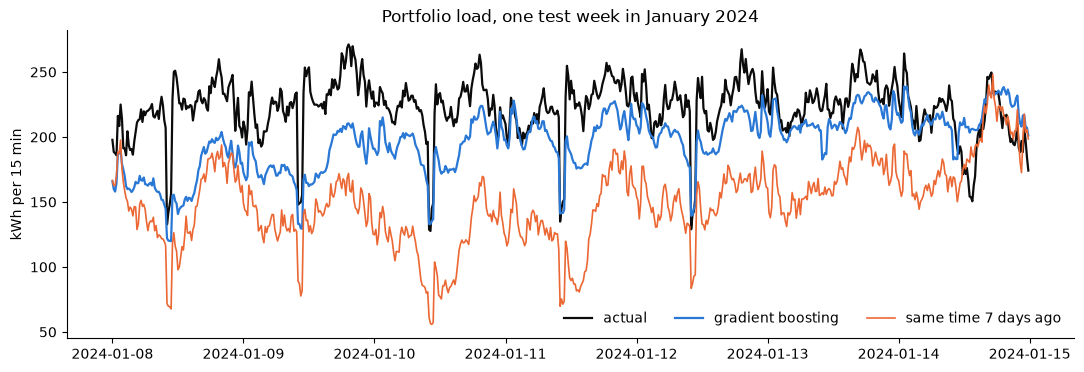

In [10]:
week = portfolio.loc["2024-01-08":"2024-01-14"]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(week.index, week["kwh"], color="#0b0b0b", linewidth=1.6, label="actual")
ax.plot(week.index, week["pred_model"], color="#2a78d6", linewidth=1.6, label="gradient boosting")
ax.plot(week.index, week["pred_lag_7d"], color="#eb6834", linewidth=1.2, label="same time 7 days ago")
ax.set(title="Portfolio load, one test week in January 2024", ylabel="kWh per 15 min")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=3)
plt.show()

## 8. Daily totals

Day-ahead energy is bought per delivery day, so this section also checks the **total energy per (local) day**. In daily totals, errors within a day partly cancel out, so the daily error is lower than the 15-min error.

- Only **complete household-days** count (≥ 92 readings: 96 per day, 92 or 100 on daylight-saving days), so a day with gaps does not look like low consumption.
- Prediction and actual are summed over exactly the same readings.

In [11]:
n_readings = fair.groupby(["Household_ID", "date"])["kwh"].transform("size")
complete = fair[n_readings >= 92]

daily_household = complete.groupby(["Household_ID", "date"])[["kwh", *PREDS.values()]].sum()
daily_portfolio = complete.groupby("date")[["kwh", *PREDS.values()]].sum()
daily_portfolio.index = pd.to_datetime(daily_portfolio.index)

print(f"{len(daily_household):,} complete household-days, {len(daily_portfolio)} portfolio days")
print("Household level (kWh per household per day)")
display(pd.DataFrame({name: scores(daily_household["kwh"], daily_household[col]) for name, col in PREDS.items()}).T.round(2))
print("Portfolio level (kWh per day, all households summed)")
display(pd.DataFrame({name: scores(daily_portfolio["kwh"], daily_portfolio[col]) for name, col in PREDS.items()}).T.round(1))

128,173 complete household-days, 361 portfolio days
Household level (kWh per household per day)


,MAE,RMSE,nMAE %,bias %
same time 2 days ago,6.71,10.96,24.93,0.39
same time 7 days ago,7.85,12.69,29.20,0.52
gradient boosting,6.52,9.96,24.26,1.94


Portfolio level (kWh per day, all households summed)


,MAE,RMSE,nMAE %,bias %
same time 2 days ago,1166.0,1753.9,12.2,0.4
same time 7 days ago,1628.5,2460.1,17.1,0.5
gradient boosting,1077.6,1551.2,11.3,1.9


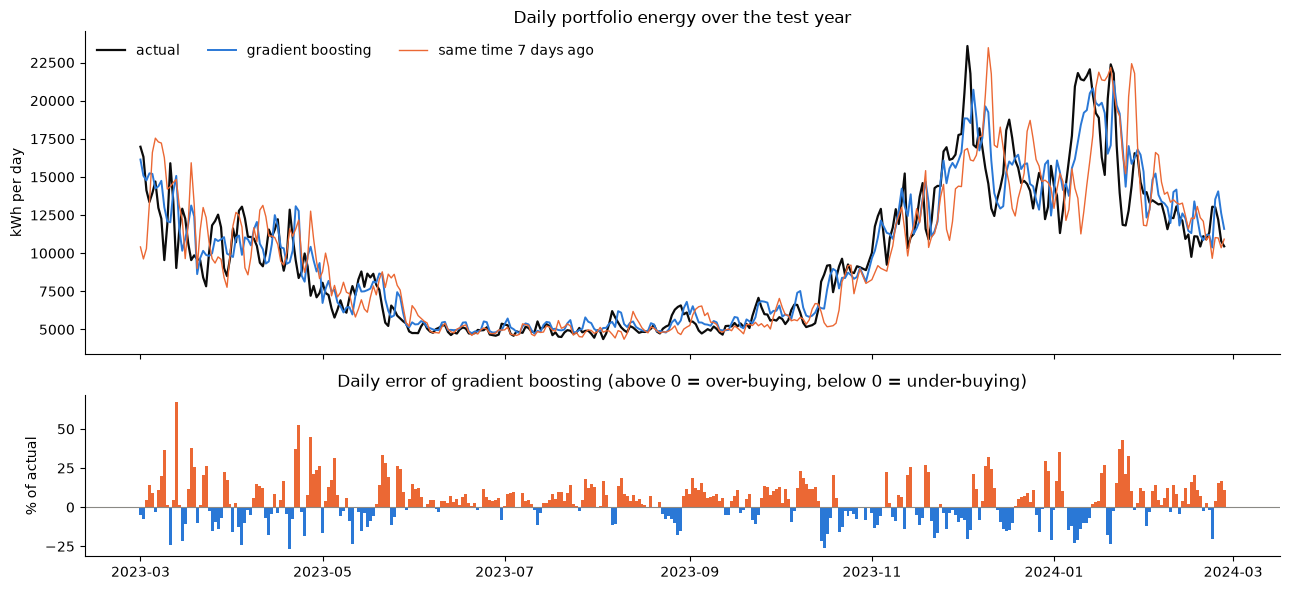

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True, height_ratios=[2, 1])
ax1.plot(daily_portfolio.index, daily_portfolio["kwh"], color="#0b0b0b", linewidth=1.6, label="actual")
ax1.plot(daily_portfolio.index, daily_portfolio["pred_model"], color="#2a78d6", linewidth=1.4, label="gradient boosting")
ax1.plot(daily_portfolio.index, daily_portfolio["pred_lag_7d"], color="#eb6834", linewidth=1.0, label="same time 7 days ago")
ax1.set(title="Daily portfolio energy over the test year", ylabel="kWh per day")
ax1.legend(frameon=False, ncol=3)

error_pct = 100 * (daily_portfolio["pred_model"] - daily_portfolio["kwh"]) / daily_portfolio["kwh"]
ax2.bar(daily_portfolio.index, error_pct, width=1, color=np.where(error_pct > 0, "#eb6834", "#2a78d6"))
ax2.axhline(0, color="#8a8984", linewidth=0.8)
ax2.set(title="Daily error of gradient boosting (above 0 = over-buying, below 0 = under-buying)", ylabel="% of actual")
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Results of both weather modes (test year, portfolio = all households summed)

| Model | 15 min, `"observed"` | 15 min, `"perfect_forecast"` | daily total, `"observed"` | daily total, `"perfect_forecast"` |
|---|---|---|---|---|
| Same time 2 days ago | 17.3 % | 17.3 % | 12.2 % | 12.2 % |
| Same time 7 days ago | 20.6 % | 20.6 % | 17.1 % | 17.1 % |
| Gradient boosting | **14.5 %** | **7.6 %** | **11.3 %** | **4.2 %** |

nMAE, run on 2026-10-06. With only weather known at the deadline, the model beats both baselines, but on daily totals only slightly beats "2 days ago": it reacts to weather changes about 2 days late. Knowing day D's weather cuts the daily error from 11.3 % to 4.2 %, which shows how much a real weather forecast is worth. A model fed by an actual forecast would land in between. See `TASK0_README.md` for the full design.

## Next steps

1. **Better weather alignment:** interpolate temperature to 15 min; add sun elevation (sunshine alone does not say *how strong* the sun is).
2. **Scale per household:** predict `kwh / household's typical load` (computed on train only), so big homes do not dominate.
3. **Heating-degree feature** `max(0, 15 - temperature)` and daily mean temperature of day D.
4. **Validation split** inside train (e.g. last winter before the test period) for tuning, keeping the test year untouched.
5. **Level 1:** separate PV / no-PV models or groups, compared with this baseline on the same test rows.
6. **Level 2/3:** cost-based metric (over- vs under-buying) and quantile forecasts (`loss="quantile"`).